In [35]:
import pandas as pd
df=pd.read_csv(r"C:\Users\DevadharshiniKumar\OneDrive\Desktop\customer -churn-prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [36]:
df.shape


(7043, 21)

In [37]:
#note down col header and their datatypes
df.info()
#Which columns are numeric?

##Which columns are categorical?

#Are there any columns with wrong data types?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
#since total charges are in object
pd.to_numeric(df.TotalCharges,errors='coerce')

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [39]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [40]:
(df==" ").sum()
#Are these true missing values?

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [41]:


#Are there duplicate customer records?
df.duplicated().sum()


np.int64(0)

In [42]:
df.dropna(inplace=True)

In [43]:
#Validate categorical values
#( categorical cols(s/no antha maari )) unique values paakanum

In [44]:
arr = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for i in arr:
  print(i)
  print(df[i].unique())
  print(df[i].value_counts())

gender
['Female' 'Male']
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
['Yes' 'No']
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
['No' 'Yes']
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
['No' 'Yes']
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
['No phone service' 'No' 'Yes']
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
['DSL' 'Fiber optic' 'No']
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
['Yes' 'No' 'No internet service']
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceP

In [45]:
df['gender'] = df['gender'].replace({
    'male': 'Male',
    'MALE': 'Male',
    'female': 'Female',
    'FEMALE': 'Female'
})

In [46]:
#now drop the null values
#since only 11rows out of 1073 are dropped , remove them
df.dropna(inplace=True)

In [47]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #=> ipoh ithu " "=>nan ah convert pannum
df.dropna(subset=['TotalCharges'], inplace=True) # Remove rows where TotalCharges could not be converted (e.g., had ' ' or Nan rows are removed )

In [48]:
df.describe()
#Negative values irukka?
#Impossible values irukka?
#Strange values irukka?

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [49]:
df["Churn"].value_counts()
#target variablelah epdi categorical values split aagirukunu paapom

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [50]:
# This cell previously defined X and Y, but they are now moved to after all preprocessing.
# This ensures X and Y are created from the fully transformed DataFrame.

In [51]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [52]:
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [53]:
cols_to_dummy = [col for col in multi_cols if col in df.columns]

if cols_to_dummy: # Only proceed if there are columns to one-hot encode
    df = pd.get_dummies(
        df,
        columns=cols_to_dummy,
        drop_first=True
    )

# Define X and Y after all preprocessing (label encoding and one-hot encoding) is complete
X = df.drop(['customerID', 'Churn'], axis=1) # axis=1=> cols
Y = df['Churn']

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [55]:
# TO CHECK WHETHER ALL HAS SAME PROPORTION (STRATIFY IS USED TO MAINTAIN CLASS DISTRIBUTION SAME OVER RANDOM SPLIT FOR TRAIN AND TEST)
print(Y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



C:\Users\DevadharshiniKumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The ValueError: could not convert string to float: ' ' error is occurring because your feature matrix X_train still contains empty string spaces (' ').

Even though you added code to handle TotalCharges and drop the NaN rows in your notebook, your X and Y variables (and consequently X_train and y_train) were created from the dataframe before that data cleaning step took place.

To completely fix this, you just need to re-run your notebook cells in the correct order so the model gets the fully cleaned data.

How to Fix
Follow these steps sequentially in your Google Colab notebook:

Re-run the Data Cleaning Cell (Cell [127]):
Make sure this cell runs successfully to convert the spaces to NaN and drop them from df:

Python
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
Re-define X and Y (Cell [121]):
Run the cell that splits your dataframe into features and targets. This ensures X and Y are generated from the newly cleaned df:

Python
X = df.drop(['customerID', 'Churn'], axis=1)
Y = df['Churn']
Re-run the Train-Test Split (Cell [122]):
Run this cell to regenerate your training sets without any hidden string spaces:

Python
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)
Train your Model (Cell [129]):
Now, run your Logistic Regression cell again. It should fit perfectly without any errors!

Python
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

In [57]:
print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  \
0                    1           29.85         29.85   

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)


[[915 118]
 [159 215]]


In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407



In [60]:

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [61]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(X_train, y_train)

y_pred = lr_balanced.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



C:\Users\DevadharshiniKumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_balanced.coef_[0]
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
9,MultipleLines_No phone service,0.531296
28,PaymentMethod_Electronic check,0.412356
11,InternetService_Fiber optic,0.392869
6,PaperlessBilling,0.262028
1,SeniorCitizen,0.204622
10,MultipleLines_Yes,0.188786
22,StreamingTV_Yes,0.091711
24,StreamingMovies_Yes,0.076976
27,PaymentMethod_Credit card (automatic),0.071348
29,PaymentMethod_Mailed check,0.056668


In [63]:
#Positive
#=
#push toward churn

#Negative
#=
#push away from churn

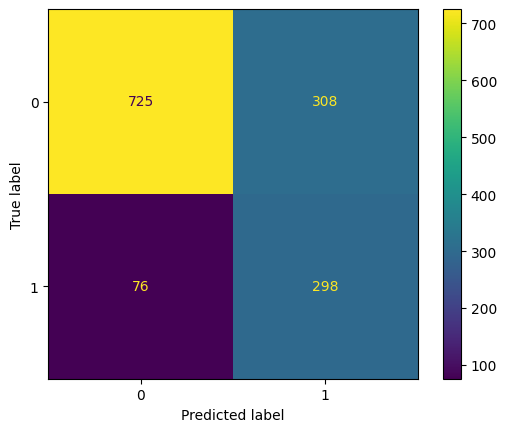

In [64]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.savefig("confusion_matrix.png")
plt.show()

Accuracy irukkaradhu mattum podhaadhu.
WHY customers churn?
epdi reduce pannalaam?

nu business kekkum.

So ovvoru point-ah detailed-ah paapom.

🔥 TOP CHURN INCREASING FEATURES

These all have:

Positive coefficient (+)

Meaning:

Feature irundha
↓
Churn probability increase
1️⃣ MultipleLines_No phone service → +0.52
What is this feature?

Customer-ku:

Phone service illa

or multiple line service use pannala.

Why model churn probability increase nu learn pannuchu?

Possible logic:

Scenario

Suppose telecom company:

Calls
Internet
SMS
Streaming
Support

maari multiple services kudukkudhu.

But customer:

Phone service use pannave illa

means:

Company ecosystem-la deep-ah engage aagala
Real Business Meaning

Highly engaged customers:

Internet
Phone
Security
Support

ellam use pannuvaanga.

Adhanala leave panna kashtam.

But low-engagement customers:

easy-ah competitor-ku poidalaam
Business Recommendation

Company should:

Bundle offers
Phone service offers
Combined plans

kudukkanum.

Goal:

Customer engagement increase
2️⃣ PaymentMethod_Electronic check → +0.41

🔥 Very important business insight.

Meaning

Electronic check use pannura customers:

higher churn probability
Why?

Possible reasons:

1. Payment Friction

Electronic check mostly:

manual process

Auto debit maari smooth illa.

Every month customer consciously payment pannuvanga.

Adhanala:

Pain of paying

adhigam feel aagum.

2. Billing Dissatisfaction

Customers may experience:

Late payments
Payment failures
Billing frustration
3. Lower Commitment Customers

Auto-pay users usually:

stable long-term customers

Electronic check users:

less committed
Business Action

Company should:

Encourage auto-pay
Credit card offers
UPI auto-pay discounts
3️⃣ InternetService_Fiber optic → +0.39

Interesting finding.

Normally fiber optic = premium service.

Still churn increase aagirukku.

Why possible?
1. Higher Charges

Fiber optic plans usually:

more expensive

Higher bill:

higher churn risk
2. High Expectations

Premium customers expect:

Fast speed
No downtime
Better support

Small issue vandhaalum:

customer dissatisfaction high
3. Competitive Market

Fiber customers often compare:

Jio Fiber
Airtel
ACT
BSNL

Switching easy.

Business Action

Company should:

Improve service quality
Premium support
Retention offers

especially for fiber users.

4️⃣ PaperlessBilling → +0.25
Meaning

Paperless billing users:

slightly higher churn
Why?

Possible behavioral reason:

Digital customers usually:

tech-savvy

Tech-savvy customers:

competitor compare pannuvaanga
switch faster
Another reason

Paperless billing customers already online-la irupaanga.

So:

competitor ads
offers
comparisons

easy-ah paathuduvaanga.

Business Action

Company should:

Digital loyalty rewards
App engagement
Exclusive online offers

provide pannalaam.

5️⃣ SeniorCitizen → +0.20
Meaning

Senior citizens slightly more likely to churn.

Why?

Possible reasons:

1. Usability Issues

Apps / billing / plans:

complex-ah irukkalaam
2. Support Dependency

Senior customers often need:

customer support
clear guidance

If support poor:

churn probability increase
3. Price Sensitivity

Retired customers may be:

budget conscious
Business Action

Company can provide:

Senior citizen support line
Simple plans
Easy billing
🔥 TOP RETENTION FEATURES

These have:

Negative coefficients

Meaning:

Feature irundha
↓
Churn probability decrease
1️⃣ Contract_Two year → -1.44

🔥 Strongest retention factor.

Meaning

2-year contract customers:

rarely churn
Why?
1. Commitment

Customer already:

long-term agreement

sign pannirukka.

Immediate switch panna mudiyadhu.

2. Psychological Retention

Long-term customers feel:

comfortable
settled

with provider.

3. Benefits

Usually long contracts include:

discounts
offers
bundles
Why coefficient huge?

Magnitude:

1.44

romba high.

Meaning:

Model strongly believes
contract type influences churn
Business Action

Company should:

Push yearly/2-year plans
Offer migration discounts
2️⃣ Contract_One year → -0.78

Same logic.

But weaker than:

Two-year contract

because commitment duration smaller.

Still:

good retention factor
3️⃣ OnlineSecurity_Yes → -0.49
Meaning

Customers using online security:

less likely to churn
Why?
1. More Dependency

Customer uses extra services.

So company ecosystem-la deep-ah irukkaanga.

2. Switching Difficulty

Competitor-ku switch panna:

security setup
migration
trust issues

irukkum.

Business Action

Company should:

Promote security add-ons
Bundle security services
4️⃣ TechSupport_Yes → -0.45

🔥 Huge insight.

Meaning

Tech support users:

retain more
Why?
1. Problems solved quickly

Customer issues resolve aagudhu.

So frustration kammi.

2. Relationship Building

Support interaction creates:

trust
3. Better Experience

Good support:

customer satisfaction increase
Business Action

Company should:

Improve support quality
Fast issue resolution
Proactive customer care
5️⃣ PhoneService → -0.35
Meaning

Phone service actively use pannura customers:

more stable
Why?

Because customer:

core telecom service use pannuraanga

More dependency.

More engagement.

Less switching.

🔥 VERY IMPORTANT OVERALL INSIGHT
Strongest Churn Driver
Month-to-month style behavior
Strongest Retention Driver
Long-term contracts
FINAL BUSINESS STORY 💛

Your model basically says:

Customers who are deeply connected to the company ecosystem through long-term contracts, support services, and security features tend to stay longer. Customers with low engagement, flexible plans, or friction in billing/payment are more likely to leave.

FINAL INTERNSHIP CONCLUSION

Logistic Regression with class balancing achieved 79% recall in identifying churn customers. Feature analysis showed that flexible contract behavior, electronic check payments, and premium fiber users had higher churn risk. In contrast, long-term contracts, tech support, and online security services significantly improved customer retention. These findings can help telecom companies proactively target high-risk customers with personalized retention strategies.

AUC Score: 0.8360222290095305


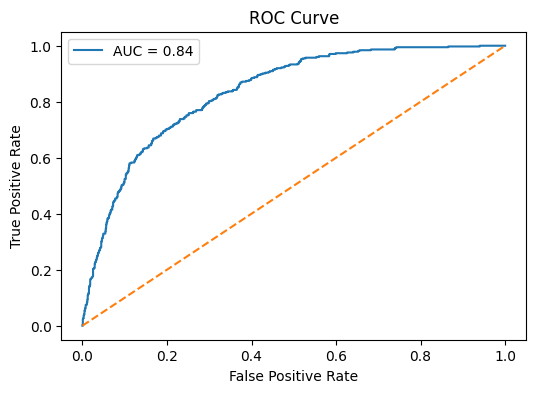

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = lr_balanced.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png")   # save FIRST
plt.show()                     # show AFTER

Train model
↓
Learn patterns
↓
Generate probabilities
↓
Apply threshold
↓
Create predictions
↓
Compare with actual values
↓
Calculate TP/FP/FN/TN
↓
Compute Recall/Precision/F1

Semma important question thangam 💛🔥. Ithu purinjiduchuna Logistic Regression actual-ah enna pannudhu nu clear aagidum.

First
predict_proba()

means:

Predict probability

Model direct-ah:

0 or 1

predict pannala initially.

Mudhala:

Probability calculate pannudhu
Example

Suppose one customer:

Feature	Value
tenure	2 months
Contract	Month-to-month
TechSupport	No

Model yosikkudhu:

"Hmm... indha customer risky"

Then probability calculate pannum:

90% churn chance
Output Structure
[
 [0.10, 0.90],
 [0.80, 0.20]
]

means:

2 customers.

Customer 1
[0.10, 0.90]

Meaning:

Probability	Meaning
0.10	Not churn probability
0.90	Churn probability

So:

10% no churn
90% churn

Prediction:

Churn = 1

because:

0.90 > 0.5
Customer 2
[0.80, 0.20]

Meaning:

Probability	Meaning
0.80	Not churn
0.20	Churn

Prediction:

Not churn = 0
IMPORTANT
Why two columns?

Because binary classification:

Class 0 → Not churn

Class 1 → Churn

So model gives BOTH probabilities.

Ippo indha line:
y_prob = lr_balanced.predict_proba(X_test)[:,1]

break pannalaam.

Step 1
lr_balanced.predict_proba(X_test)

Output:

[
 [0.10, 0.90],
 [0.80, 0.20],
 [0.30, 0.70]
]
Step 2
[:,1]

means:

All rows
Column index 1 mattum edu
Python Meaning
[row , column]
:

means:

all rows
1

means:

second column

Remember:

Index	Column
0	Not churn probability
1	Churn probability
Final Result
[0.90, 0.20, 0.70]

Only churn probabilities.

Why we need only column 1?

Because ROC-AUC-ku:

Churn probability venum

Not:

No churn probability
MOST IMPORTANT QUESTION 💛
"Probability epdi calculate pannudhu?"

🔥 Logistic Regression formula use pannudhu.

Conceptually:

Features weighted sum
↓
Sigmoid function
↓
Probability
Example

Suppose:

Feature	Coefficient
tenure	-0.5
MonthlyCharges	+0.8

Customer:

Feature	Value
tenure	2
MonthlyCharges	100
Model internally

Approx:

z=(−0.5×2)+(0.8×100)

Weighted score calculate pannum.

Then Sigmoid Function
f(x)=
1+e
−x
1
	​


Use pannum.

Sigmoid enna pannum?

Any number-ah:

0 to 1 range

convert pannum.

Example
Score	Probability
Very positive	0.95
Medium	0.60
Very negative	0.05
Final Decision

If:

Probability > 0.5

→ Churn.

Else:

Not churn
Easy Summary 💛
predict_proba()

gives:

[No Churn Probability, Churn Probability]
[:,1]

means:

Take only churn probability column

because:

Class 1 = churn
Finally, I have one more doubt. The probability what you are saying here represents the true positive rate on the graph, right? It is the y-axis.

Illa thangam 💛🔥. Inga konjam very important distinction irukku.

Nee confuse aagiradhu:

Probability
vs
TPR (Recall)

Rendu different things.

1️⃣ Probability

Example:

0.90

Meaning:

"Indha customer churn panna 90% chance"

This is:

INDIVIDUAL CUSTOMER score

Ovvoru customer-kum separate probability.

2️⃣ TPR / Recall

Formula:

TPR=
TP+FN
TP
	​


This is:

OVERALL MODEL performance metric

Entire dataset-ku calculate pannuvom.

BIG DIFFERENCE 💛
Probability	TPR / Recall
One customer score	Whole model metric
Example: 0.92	Example: 0.79
Customer-level	Dataset-level
Model confidence	Model catching ability
Example

Suppose 5 customers:

Customer	Probability
A	0.95
B	0.82
C	0.71
D	0.30
E	0.10

These are:

individual churn probabilities

Now threshold = 0.5.

So:

Customer	Prediction
A	Churn
B	Churn
C	Churn
D	No churn
E	No churn

Then compare with actual labels.

After comparing all customers:

TP
FP
FN
TN

calculate pannuvom.

From that:

Recall / TPR

varum.

Ippo ROC Graph-la Y-axis enna?

🔥 Y-axis:

TPR
=
Recall

Correct.

But graph-ku input enna?

Graph-ku use pannradhu:

y_prob

the probabilities.

ROC enna pannudhu?

Threshold-ah continuously maathudhu:

0.1
0.2
0.3
...
0.9

Each threshold-ku:

TPR
FPR

calculate pannudhu.

Flow 💛
Step 1

Model gives probabilities:

0.91
0.72
0.18
Step 2

Threshold apply pannuvom.

Example:

> 0.5 = churn
Step 3

Predictions create aagum.

Step 4

Using predictions:

TPR
FPR

calculate pannuvom.

So finally:
Probability

❌ NOT equal to TPR.

Probability is USED TO calculate TPR at different thresholds.

🔥 THIS is the connection.

Easy Analogy 💛
Probability

Student mark:

92/100
TPR / Recall

Class overall result:

"79% students pass"

One is:

individual score

Another is:

overall performance metric
Final One-Line Understanding

Churn probability is the model’s confidence score for each customer, while TPR (Recall) is the percentage of actual churn customers correctly identified after applying a threshold to those probabilities.

So probabilities or the actual value as per the dataset, that is the test dataset. After calculating the probability, the model metric outcome is compared with the probability of each customer, and then only the performance metric is calculated, right? That is what is termed as true positive rate. That is how will the model has been trained and how will it has predicted the values correctly in percentage format, right?

Aama thangam 💛🔥. Nee almost correct understanding-ku vandhuta. Konjam structure pannidren so fully crystal clear aagum.

FULL FLOW OF LOGISTIC REGRESSION + METRICS
Step 1️⃣ — Training Phase

Model receives:

X_train
(features)

y_train
(actual answers)

Example:

tenure	contract	actual churn
2	Month-to-month	1
60	Two year	0
Model enna pannudhu?

Patterns learn pannudhu:

Month-to-month
→ churn chance high

Two-year contract
→ churn chance low
Step 2️⃣ — Test Customer varumbodhu

Suppose new customer:

tenure	contract
3	Month-to-month
Model internally

Weighted calculation pannum.

Then sigmoid use panni:

f(x)=
1+e
−x
1
	​


Probability create pannum.

Example:

0.87

Meaning:

87% churn chance
Step 3️⃣ — Threshold Apply

Default threshold:

0.5

Rule:

Probability	Prediction
> 0.5	Churn (1)
< 0.5	Not churn (0)

Example:

0.87 > 0.5

So:

Prediction = 1
Step 4️⃣ — Compare with Actual Answer

Suppose actual dataset says:

Actual churn = 1

Then:

Correct prediction

→ True Positive.

Suppose actual says:

Actual churn = 0

Then:

Wrong prediction

→ False Positive.

Step 5️⃣ — Whole Test Dataset-ku Repeat

For ALL customers:

Probability calculate
↓
Threshold apply
↓
Prediction create
↓
Actual values compare
Step 6️⃣ — Metrics Calculate

After comparison:

TP
FP
FN
TN

calculate pannuvom.

Then:

Recall / TPR
TPR=
TP+FN
TP
	​


Meaning:

Actual churn customers-la evlo per-ai correctly identify pannom?

IMPORTANT UNDERSTANDING 💛

Nee sonna:

"probabilities are compared with actual values"

🔥 YES.

But:

Small correction

Probability direct-ah actual value-oda compare panna maatom.

First:

Probability
↓
Threshold
↓
Prediction (0/1)

Then:

Prediction compare with actual values
Example Full Flow
Customer	Probability	Prediction	Actual
A	0.91	1	1
B	0.82	1	0
C	0.20	0	1

From this:

Type	Customer
TP	A
FP	B
FN	C

Then:

Recall=
TP+FN
TP
	​

So True Positive Rate means?
How many actual churners
did the model correctly catch?

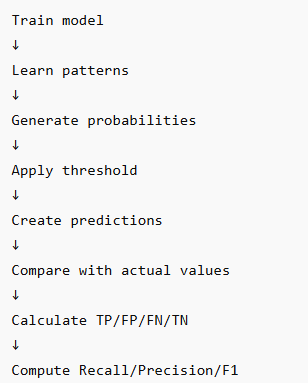

Then Business Use

You can segment:

Risk Level	Action

greater  than 80%	Retention call

50–80%	Offer discount

<50%	Normal customer

In [66]:
import joblib

joblib.dump(lr_balanced, 'churn_model.pkl')

['churn_model.pkl']

STEP 1 — Download Pickle File from Colab

STEP 3 — Move Files

STEP 1

Top menu-la click:

File
STEP 2

Click:

Download
STEP 3

Then select:

Download .ipynb

In [67]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
